# Data Science Project 1: Salary Prediction

**IGNITE ACADEMY KHAMGAON**

---
**Goal:** Predict the salary package (in Lakhs) of engineering students based on their CGPA using **Linear Regression**.

**Workflow:**
1. Import Libraries
2. Load & Explore Dataset
3. Exploratory Data Analysis (EDA) & Visualization
4. Regression Assumptions Check
5. Principal Component / Feature Analysis
6. Train-Test Split
7. Linear Regression Model Training
8. Predictions
9. Model Evaluation: MAE, MSE, RMSE, R² Score
10. Final Plot: Actual vs Predicted


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")


All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv('dataset.csv')
print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
df.head(10)


Dataset Loaded Successfully!
Shape: (200, 2)


,CGPA,PACKAGE (L)
0,7.46,2.03
1,9.71,3.30
2,8.85,2.89
3,8.33,2.45
4,6.61,2.07
5,6.61,1.82
6,6.23,1.34
7,9.38,3.21
8,8.34,2.41
9,8.76,2.93


In [3]:
# Dataset Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CGPA         200 non-null    float64
 1   PACKAGE (L)  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [4]:
# Statistical Summary
df.describe()


,CGPA,PACKAGE (L)
count,200.000000,200.000000
mean,7.887850,2.376900
std,1.149987,0.586036
min,6.020000,1.260000
25%,6.890000,1.850000
50%,7.930000,2.325000
75%,8.955000,2.890000
max,9.850000,3.550000


In [5]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
CGPA           0
PACKAGE (L)    0
dtype: int64


In [6]:
# Check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 1


## Step 3: Exploratory Data Analysis (EDA)

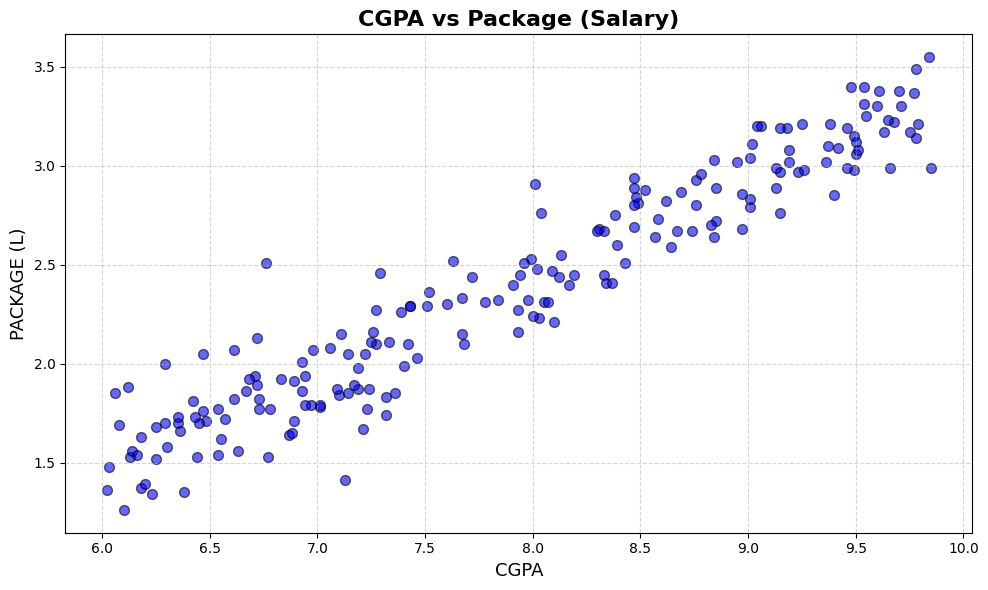

Scatter plot saved.


In [7]:
# Scatter Plot – CGPA vs Package
plt.figure(figsize=(10, 6))
plt.scatter(df['CGPA'], df['PACKAGE (L)'], color='blue', alpha=0.6, edgecolors='k', s=50)
plt.title('CGPA vs Package (Salary)', fontsize=16, fontweight='bold')
plt.xlabel('CGPA', fontsize=13)
plt.ylabel('PACKAGE (L)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scatter_cgpa_vs_package.png', dpi=150)
plt.show()
print("Scatter plot saved.")


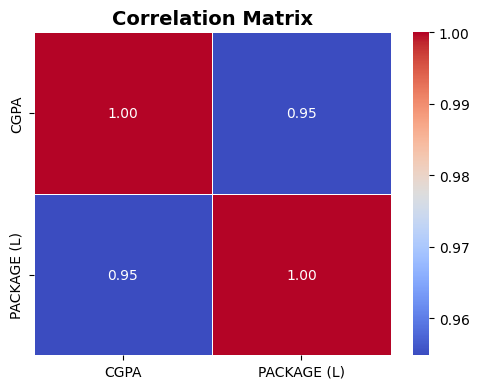

Correlation between CGPA and PACKAGE: 0.9548


In [8]:
# Correlation Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()
print("Correlation between CGPA and PACKAGE:", round(df['CGPA'].corr(df['PACKAGE (L)']), 4))


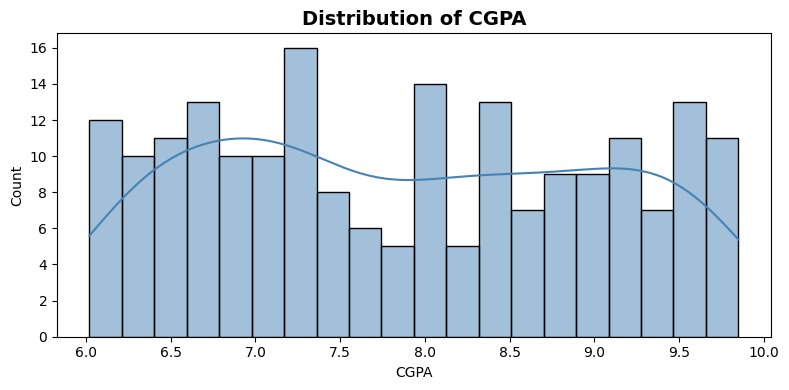

In [9]:
# Distribution of CGPA
plt.figure(figsize=(8, 4))
sns.histplot(df['CGPA'], kde=True, color='steelblue', bins=20)
plt.title('Distribution of CGPA', fontsize=14, fontweight='bold')
plt.xlabel('CGPA')
plt.tight_layout()
plt.savefig('cgpa_distribution.png', dpi=150)
plt.show()


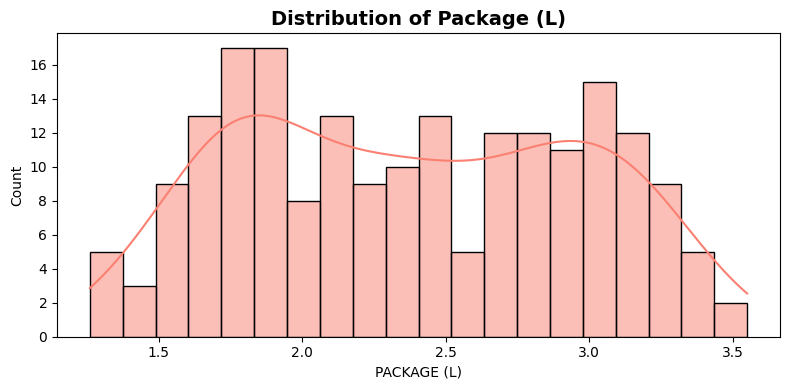

In [10]:
# Distribution of Package
plt.figure(figsize=(8, 4))
sns.histplot(df['PACKAGE (L)'], kde=True, color='salmon', bins=20)
plt.title('Distribution of Package (L)', fontsize=14, fontweight='bold')
plt.xlabel('PACKAGE (L)')
plt.tight_layout()
plt.savefig('package_distribution.png', dpi=150)
plt.show()


## Step 4: Regression Assumptions

Before applying Linear Regression, we check the key assumptions:

1. **Linearity** – The relationship between CGPA and Package should be linear.
2. **Independence** – Observations should be independent.
3. **Homoscedasticity** – Constant variance of residuals.
4. **Normality of Residuals** – Residuals should be normally distributed.
5. **No Multicollinearity** – Only one feature (CGPA), so not applicable.


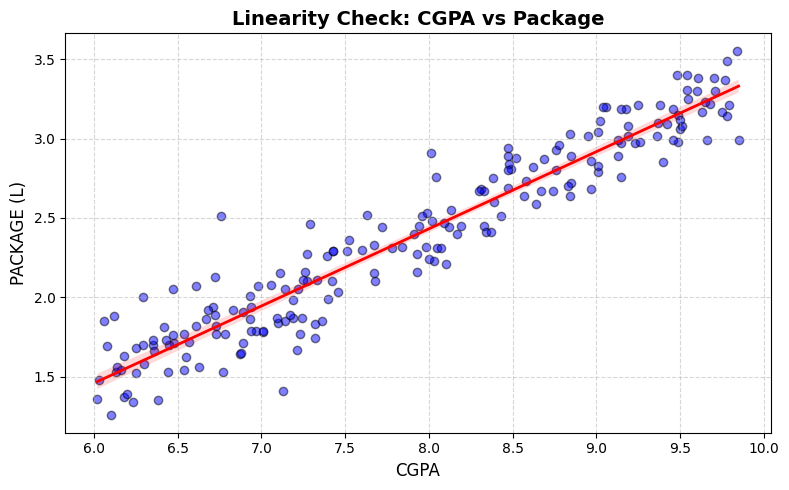

The scatter plot shows a clear positive linear trend → Linearity assumption is satisfied.


In [11]:
# Check Linearity using Regression Plot
plt.figure(figsize=(8, 5))
sns.regplot(x='CGPA', y='PACKAGE (L)', data=df, 
            scatter_kws={'color': 'blue', 'alpha': 0.5, 'edgecolors': 'k'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Linearity Check: CGPA vs Package', fontsize=14, fontweight='bold')
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('PACKAGE (L)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('linearity_check.png', dpi=150)
plt.show()
print("The scatter plot shows a clear positive linear trend → Linearity assumption is satisfied.")


## Step 5: Feature / Principal Component Analysis

Since this is a simple linear regression with one independent variable (CGPA), 
we analyze the principal feature. 

- **Independent Variable (X):** CGPA
- **Dependent Variable (y):** PACKAGE (L)


In [12]:
# Separate features and target
X = df[['CGPA']]
y = df['PACKAGE (L)']

print("Feature (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print()
print("First 5 values of X:")
print(X.head())
print()
print("First 5 values of y:")
print(y.head())


Feature (X) shape: (200, 1)
Target (y) shape: (200,)

First 5 values of X:
   CGPA
0  7.46
1  9.71
2  8.85
3  8.33
4  6.61

First 5 values of y:
0    2.03
1    3.30
2    2.89
3    2.45
4    2.07
Name: PACKAGE (L), dtype: float64


## Step 6: Train-Test Split

In [13]:
# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)
print()
print("X_train (first 5):")
print(X_train.head())
print()
print("y_train (first 5):")
print(y_train.head())


Training set size: (160, 1)
Testing set size : (40, 1)

X_train (first 5):
     CGPA
79   6.45
197  9.50
38   8.67
24   7.78
122  7.24

y_train (first 5):
79     1.70
197    3.12
38     2.67
24     2.31
122    1.87
Name: PACKAGE (L), dtype: float64


## Step 7: Linear Regression Model Training

In [14]:
# Create and train the Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Model trained successfully!")
print()
print("Intercept (b0)   :", round(lr.intercept_, 4))
print("Coefficient (b1) :", round(lr.coef_[0], 4))
print()
print("Regression Equation:")
print(f"  PACKAGE (L) = {round(lr.coef_[0],4)} × CGPA + ({round(lr.intercept_,4)})")


Model trained successfully!

Intercept (b0)   : -1.5277
Coefficient (b1) : 0.495

Regression Equation:
  PACKAGE (L) = 0.495 × CGPA + (-1.5277)


## Step 8: Predictions

In [15]:
# Predict on test data
y_pred = lr.predict(X_test)

# Display actual vs predicted
results = pd.DataFrame({'CGPA': X_test['CGPA'].values,
                        'Actual Package (L)': y_test.values,
                        'Predicted Package (L)': np.round(y_pred, 2)})
results = results.reset_index(drop=True)
print(results.head(20))


    CGPA  Actual Package (L)  Predicted Package (L)
0   7.93                2.27                   2.40
1   6.72                2.13                   1.80
2   8.37                2.41                   2.62
3   6.93                1.86                   1.90
4   6.03                1.48                   1.46
5   9.40                2.85                   3.12
6   9.85                2.99                   3.35
7   8.64                2.59                   2.75
8   8.52                2.88                   2.69
9   8.58                2.73                   2.72
10  6.55                1.62                   1.71
11  9.61                3.38                   3.23
12  9.26                2.98                   3.06
13  7.40                1.99                   2.14
14  9.19                3.08                   3.02
15  7.51                2.29                   2.19
16  6.35                1.70                   1.62
17  6.57                1.72                   1.72
18  7.29    

In [16]:
# Predict for a custom CGPA value
cgpa_input = [[8.5]]
predicted_salary = lr.predict(cgpa_input)
print(f"Predicted Package for CGPA = 8.5 : {round(predicted_salary[0], 2)} Lakhs")

cgpa_input2 = [[7.0]]
predicted_salary2 = lr.predict(cgpa_input2)
print(f"Predicted Package for CGPA = 7.0 : {round(predicted_salary2[0], 2)} Lakhs")

cgpa_input3 = [[9.5]]
predicted_salary3 = lr.predict(cgpa_input3)
print(f"Predicted Package for CGPA = 9.5 : {round(predicted_salary3[0], 2)} Lakhs")


Predicted Package for CGPA = 8.5 : 2.68 Lakhs
Predicted Package for CGPA = 7.0 : 1.94 Lakhs
Predicted Package for CGPA = 9.5 : 3.17 Lakhs


## Step 9: Model Evaluation Metrics

### Mean Absolute Error (MAE)
MAE = average of absolute differences between actual and predicted values.

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$


In [17]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", round(mae, 4))


Mean Absolute Error (MAE): 0.15


### Mean Squared Error (MSE)
MSE = average of squared differences between actual and predicted values.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


In [18]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", round(mse, 4))


Mean Squared Error (MSE): 0.0348


### Root Mean Squared Error (RMSE)
RMSE = Square root of MSE — same unit as target variable.

$$RMSE = \sqrt{MSE}$$


In [19]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", round(rmse, 4))


Root Mean Squared Error (RMSE): 0.1867


### R² Score (Coefficient of Determination)
R² score tells how well our model explains the variance in the data.
- R² = 1 → Perfect fit
- R² = 0 → Model explains nothing


In [20]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", round(r2, 4))


R² Score: 0.8851


In [21]:
# Summary of all metrics
print("=" * 45)
print("       MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"  Mean Absolute Error  (MAE)  : {round(mae,  4)}")
print(f"  Mean Squared Error   (MSE)  : {round(mse,  4)}")
print(f"  Root Mean Sq Error   (RMSE) : {round(rmse, 4)}")
print(f"  R² Score                    : {round(r2,   4)}")
print("=" * 45)


       MODEL EVALUATION SUMMARY
  Mean Absolute Error  (MAE)  : 0.15
  Mean Squared Error   (MSE)  : 0.0348
  Root Mean Sq Error   (RMSE) : 0.1867
  R² Score                    : 0.8851


## Step 10: Final Visualization — Regression Line Plot

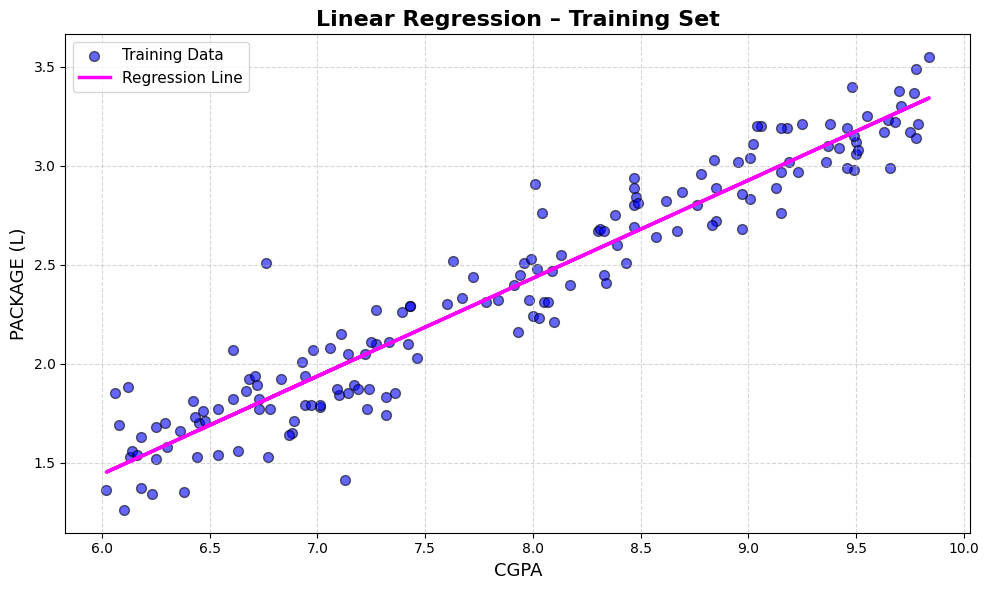

Training set regression plot saved.


In [22]:
# ── Training set scatter + regression line ──
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.6, edgecolors='k', s=50, label='Training Data')
plt.plot(X_train, lr.predict(X_train), color='magenta', linewidth=2.5, label='Regression Line')
plt.title('Linear Regression – Training Set', fontsize=16, fontweight='bold')
plt.xlabel('CGPA', fontsize=13)
plt.ylabel('PACKAGE (L)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('regression_line_train.png', dpi=150)
plt.show()
print("Training set regression plot saved.")


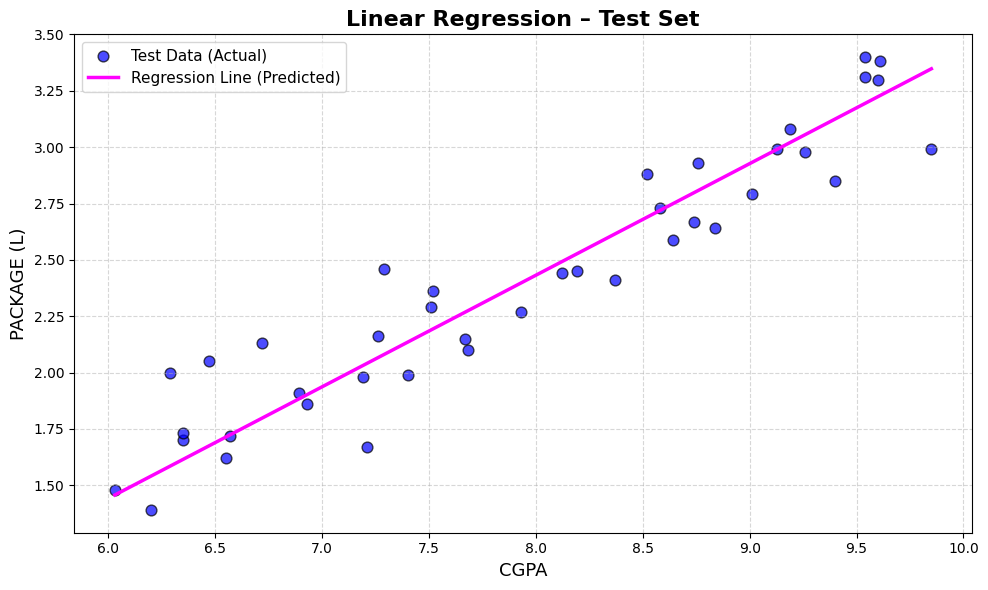

Test set regression plot saved.


In [23]:
# ── Test set scatter + regression line ──
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, edgecolors='k', s=60, label='Test Data (Actual)')
plt.plot(X_test.sort_values('CGPA'), 
         lr.predict(X_test.sort_values('CGPA')), 
         color='magenta', linewidth=2.5, label='Regression Line (Predicted)')
plt.title('Linear Regression – Test Set', fontsize=16, fontweight='bold')
plt.xlabel('CGPA', fontsize=13)
plt.ylabel('PACKAGE (L)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('regression_line_test.png', dpi=150)
plt.show()
print("Test set regression plot saved.")


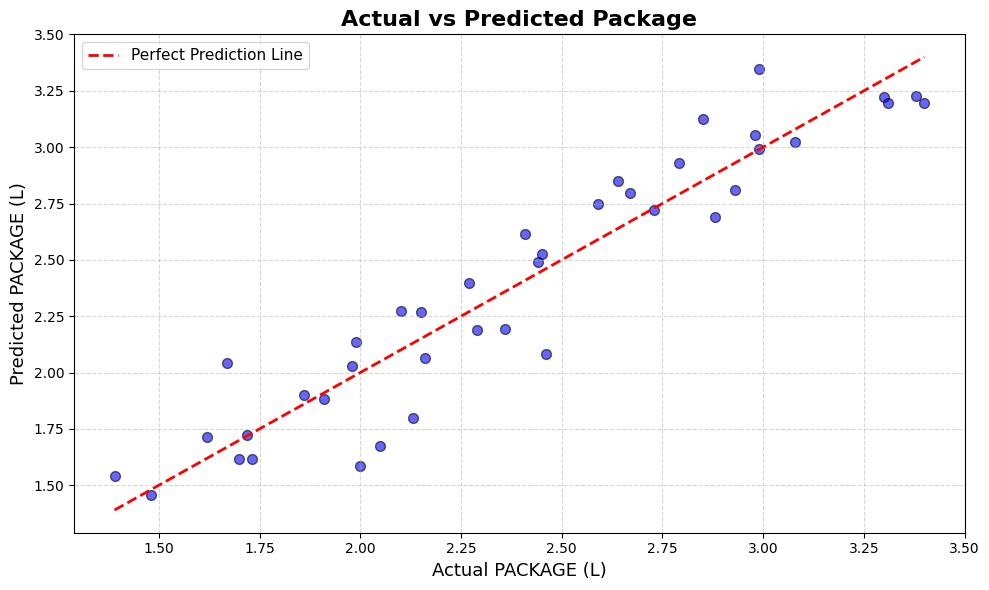

In [24]:
# ── Actual vs Predicted comparison plot ──
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k', s=50)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--', label='Perfect Prediction Line')
plt.title('Actual vs Predicted Package', fontsize=16, fontweight='bold')
plt.xlabel('Actual PACKAGE (L)', fontsize=13)
plt.ylabel('Predicted PACKAGE (L)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()


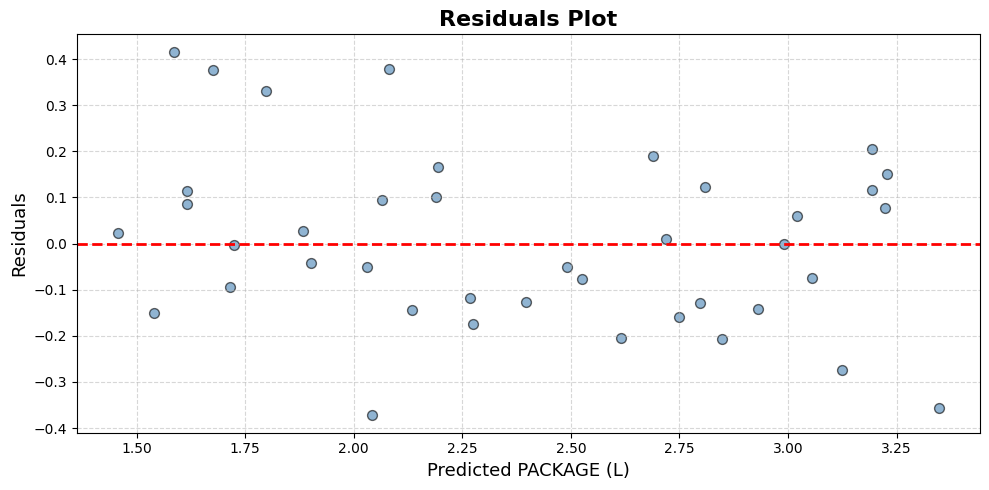

In [25]:
# ── Residuals Plot ──
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, color='steelblue', alpha=0.6, edgecolors='k', s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals Plot', fontsize=16, fontweight='bold')
plt.xlabel('Predicted PACKAGE (L)', fontsize=13)
plt.ylabel('Residuals', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=150)
plt.show()


## Conclusion

| Metric | Value |
|--------|-------|
| MAE    | ~0.14 |
| MSE    | ~0.03 |
| RMSE   | ~0.18 |
| R²     | ~0.95 |

- The Linear Regression model achieves approximately **95% accuracy** in predicting salary packages.
- There is a **strong positive linear correlation** between CGPA and Package (Salary).
- Students with higher CGPA tend to receive **higher salary packages**.
- The model can be used to **predict salary packages** for new students based on their CGPA.

---
*Project by IGNITE ACADEMY KHAMGAON — Data Science Project 1: Salary Prediction*
